In [4]:
import pandas as pd
from typing import List, Dict, Tuple

def p_star_teorico(
    ruta_ciudades: str,
    ruta_hospitales: str,
    H: int = 30,
    LOS: int = 5,
    occ_target: float = 0.85,   # holgura/ocupación objetivo (<=1). Baja este valor para más colchón.
    rhos: List[float] = [0.005, 0.01, 0.02, 0.05, 0.08],  # 0.5%, 1%, 2%, 5%, 8%
    p_grid: List[int] = [10,12,15,18,20,25,30,35,40]
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Devuelve:
      - df_grid: tabla larga con filas (rho, p) y métricas (Q, C_top_p, util=Q/C_top_p, feasible)
      - df_pstar: resumen por rho con p* mínimo factible y métricas asociadas
    """
    ciudades = pd.read_csv(ruta_ciudades)      # requiere columna 'poblacion'
    hospitales = pd.read_csv(ruta_hospitales)  # requiere columna 'capacidad'

    # Capacidad rotatoria en H días con ocupación objetivo (holgura)
    hospitales = hospitales.copy()
    hospitales["C"] = hospitales["capacidad"] * (H / LOS) * occ_target
    hospitales = hospitales.sort_values("C", ascending=False).reset_index(drop=True)

    # Precalcula acumulado de capacidad top-p
    hospitales["C_cum"] = hospitales["C"].cumsum()

    rows = []
    pstar_rows = []

    for rho in rhos:
        # Demanda total esperada en H días
        Q = float(ciudades["poblacion"].sum() * rho)

        # Para cada p del grid, mira si la capacidad acumulada top-p cubre Q
        p_found = None
        for p in p_grid:
            if p > len(hospitales):
                # por si el grid sobrepasa nº hospitales disponibles
                C_top_p = hospitales["C"].sum()
            else:
                C_top_p = float(hospitales.loc[p-1, "C_cum"])  # acumulado hasta índice p-1

            util = Q / C_top_p if C_top_p > 0 else float("inf")
            feasible = (C_top_p >= Q)

            rows.append({
                "rho": rho,
                "p": p,
                "Q_demand": Q,
                "C_top_p": C_top_p,
                "utilization_Q_over_C": util,  # <1 implica holgura
                "feasible": int(feasible)      # 1 si cubre Q con la holgura deseada
            })

            if feasible and p_found is None:
                p_found = (p, Q, C_top_p, util)

        # Si existe p* para este rho, guárdalo; si no, marca sin factibilidad
        if p_found is not None:
            p_opt, Qopt, Copt, utilopt = p_found
            pstar_rows.append({
                "rho": rho,
                "p_star": p_opt,
                "Q_demand": Qopt,
                "C_top_p_star": Copt,
                "utilization_at_p_star": utilopt,  # cuanto menor, más colchón
                "coverage_margin": (Copt - Qopt)   # margen absoluto de capacidad
            })
        else:
            pstar_rows.append({
                "rho": rho,
                "p_star": None,
                "Q_demand": Q,
                "C_top_p_star": hospitales["C"].sum(),
                "utilization_at_p_star": Q / max(hospitales["C"].sum(), 1e-9),
                "coverage_margin": hospitales["C"].sum() - Q
            })

    df_grid = pd.DataFrame(rows)
    df_pstar = pd.DataFrame(pstar_rows)

    # Orden bonito
    df_grid = df_grid.sort_values(["rho", "p"]).reset_index(drop=True)
    df_pstar = df_pstar.sort_values("rho").reset_index(drop=True)
    return df_grid, df_pstar

# === Ejemplo de uso ===
df_grid, df_pstar = p_star_teorico(
    ruta_ciudades="../data/processed/andaluces_2_5k.csv",
    ruta_hospitales="../data/processed/Hospitales_Completo.csv",
    H=30, LOS=5, occ_target=1,  # occ_target más bajo = más holgura
    rhos=[0.0001, 0.0005,0.001,0.005, 0.01],
    p_grid=[10,15,20,30,50]
)
# df_grid.to_csv("runs/teorico_grid.csv", index=False)
# df_pstar.to_csv("runs/teorico_pstar.csv", index=False)
display(df_pstar)


,rho,p_star,Q_demand,C_top_p_star,utilization_at_p_star,coverage_margin
0,0.0001,10,818.5809,41172.0,0.019882,40353.4191
1,0.0005,10,4092.9045,41172.0,0.099410,37079.0955
2,0.0010,10,8185.8090,41172.0,0.198820,32986.1910
3,0.0050,10,40929.0450,41172.0,0.994099,242.9550
4,0.0100,50,81858.0900,105012.0,0.779512,23153.9100


In [5]:
from typing import List, Tuple, Optional
import numpy as np
import matplotlib.pyplot as plt
def p_star_teorico(
    ruta_ciudades: str,
    ruta_hospitales: str,
    H: int = 30,
    LOS: int = 5,
    occ_target: float = 0.85,
    rhos: List[float] = [0.005, 0.01, 0.02, 0.05, 0.08],   # 0.5%, 1%, 2%, 5%, 8%
    p_grid: List[int] = [10,12,15,18,20,25,30,35,40,45,50,60,80]
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Devuelve:
      - df_grid: filas (rho, p) con Q, C_top_p, utilización y factibilidad teórica
      - df_pstar: por rho, el mínimo p que cubre Q (teórico, sin geografía)
    Además guarda CSV en runs/.
    """

    ciudades = pd.read_csv(ruta_ciudades)      # requiere 'poblacion'
    hospitales = pd.read_csv(ruta_hospitales)  # requiere 'capacidad'

    # Capacidad rotatoria en H días con ocupación objetivo (holgura)
    hos = hospitales.copy()
    hos["C"] = hos["capacidad"] * (H / LOS) * occ_target
    hos = hos.sort_values("C", ascending=False).reset_index(drop=True)
    hos["C_cum"] = hos["C"].cumsum()

    rows = []
    pstar_rows = []

    for rho in rhos:
        Q = float(ciudades["poblacion"].sum() * rho)
        p_found = None

        for p in p_grid:
            # Acumulado top-p
            if p > len(hos):
                C_top_p = float(hos["C"].sum())
            else:
                C_top_p = float(hos.loc[p-1, "C_cum"])
            util = Q / C_top_p if C_top_p > 0 else float("inf")
            feasible = int(C_top_p >= Q)

            rows.append({
                "rho": rho,
                "p": p,
                "Q_demand": Q,
                "C_top_p": C_top_p,
                "utilization_Q_over_C": util,
                "feasible": feasible
            })
            if feasible and p_found is None:
                p_found = (p, Q, C_top_p, util)

        if p_found is not None:
            p_opt, Qopt, Copt, utilopt = p_found
            pstar_rows.append({
                "rho": rho,
                "p_star": p_opt,
                "Q_demand": Qopt,
                "C_top_p_star": Copt,
                "utilization_at_p_star": utilopt,
                "coverage_margin": (Copt - Qopt)
            })
        else:
            # No cubre ni con todos
            C_all = float(hos["C"].sum())
            pstar_rows.append({
                "rho": rho,
                "p_star": None,
                "Q_demand": Q,
                "C_top_p_star": C_all,
                "utilization_at_p_star": (Q / max(C_all, 1e-9)),
                "coverage_margin": (C_all - Q)
            })

    df_grid = pd.DataFrame(rows).sort_values(["rho", "p"]).reset_index(drop=True)
    df_pstar = pd.DataFrame(pstar_rows).sort_values("rho").reset_index(drop=True)

    return df_grid, df_pstar


# -------------------------------------------------
# 2) Curva C_top_p vs p (no depende de rho)
# -------------------------------------------------
def plot_capacity_curve(
    ruta_hospitales: str,
    H: int = 30,
    LOS: int = 5,
    occ_target: float = 0.85,
    p_max: Optional[int] = None
) -> None:
    """
    Traza C_top_p (capacidad acumulada) vs p con ocupación objetivo occ_target.
    """
   

    hospitales = pd.read_csv(ruta_hospitales)
    hos = hospitales.copy()
    hos["C"] = hos["capacidad"] * (H / LOS) * occ_target
    hos = hos.sort_values("C", ascending=False).reset_index(drop=True)
    hos["C_cum"] = hos["C"].cumsum()

    n = len(hos) if p_max is None else min(p_max, len(hos))
    p_vals = np.arange(1, n + 1)
    C_vals = hos.loc[:n-1, "C_cum"].values

    plt.figure()
    plt.plot(p_vals, C_vals)
    plt.xlabel("p (nº de hospitales)")
    plt.ylabel("Capacidad acumulada en H días (personas)")
    plt.title("Curva C_top_p vs p (capacidad acumulada con holgura)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# === Ejemplo de uso ===
DIST = "../data/matrix/time_ciudad_hospital_min.csv"
CITIES = "../data/processed/Ciudades_Con_Demanda.csv"
HOSPS = "../data/processed/Hospitales_Con_Capacidad.csv"

# Parámetros globales
H = 30
LOS = 5
OCC = 0.85
RHOS = [0.001, 0.005, 0.01]
P_GRID_EXT = [5,8,10,15,20,25,30,60,70]

# 1) Tablas teóricas con p_grid extendido
df_grid, df_pstar = p_star_teorico(
    ruta_ciudades=CITIES, ruta_hospitales=HOSPS,
    H=H, LOS=LOS, occ_target=OCC,
    rhos=RHOS, p_grid=P_GRID_EXT
)
display(df_pstar)
print(df_grid[df_grid['feasible']==1])


,rho,p_star,Q_demand,C_top_p_star,utilization_at_p_star,coverage_margin
0,0.001,5,8185.809,19206.6,0.426198,11020.791
1,0.005,15,40929.045,47011.8,0.870612,6082.755
2,0.010,60,81858.090,96420.6,0.848969,14562.510


      rho   p   Q_demand   C_top_p  utilization_Q_over_C  feasible
0   0.001   5   8185.809   19206.6              0.426198         1
1   0.001   8   8185.809   28906.8              0.283179         1
2   0.001  10   8185.809   34996.2              0.233906         1
3   0.001  15   8185.809   47011.8              0.174122         1
4   0.001  20   8185.809   55590.0              0.147253         1
5   0.001  25   8185.809   62837.1              0.130270         1
6   0.001  30   8185.809   69089.7              0.118481         1
7   0.001  60   8185.809   96420.6              0.084897         1
8   0.001  70   8185.809  102081.6              0.080189         1
12  0.005  15  40929.045   47011.8              0.870612         1
13  0.005  20  40929.045   55590.0              0.736266         1
14  0.005  25  40929.045   62837.1              0.651352         1
15  0.005  30  40929.045   69089.7              0.592404         1
16  0.005  60  40929.045   96420.6              0.424484      

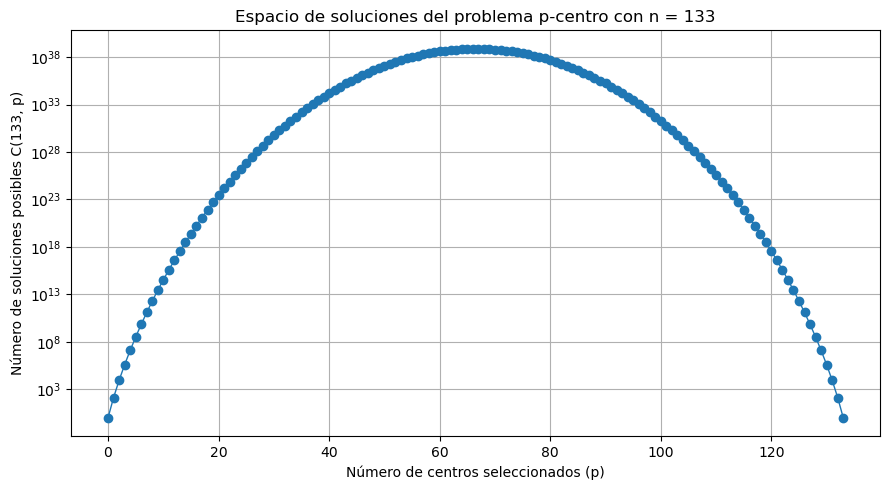

p=  0 -> C(133, 0) = 1
p=  1 -> C(133, 1) = 133
p=  2 -> C(133, 2) = 8778
p=  5 -> C(133, 5) = 321402081
p= 10 -> C(133, 10) = 337429331439200
p= 20 -> C(133, 20) = 273985965468577071910200
p= 50 -> C(133, 50) = 12393970707045711042194767822455825360
p= 66 -> C(133, 66) = 749146650746521593754190788877936298300
p= 67 -> C(133, 67) = 749146650746521593754190788877936298300
p=100 -> C(133, 100) = 18352730289990803836919962151980
p=133 -> C(133, 133) = 1


In [6]:
import math
import matplotlib.pyplot as plt

# Número total de localizaciones candidatas (longitud de solución)
n = 133

# p desde 0 hasta n (puedes cambiar el rango si quieres empezar en 1)
p_values = list(range(0, n + 1))

# Número de soluciones posibles: combinaciones C(n, p)
solutions = [math.comb(n, p) for p in p_values]

# --- Gráfica ---
plt.figure(figsize=(9, 5))
plt.plot(p_values, solutions, marker='o', linewidth=1)
plt.yscale('log')  # Escala logarítmica para visualizar mejor
plt.xlabel('Número de centros seleccionados (p)')
plt.ylabel('Número de soluciones posibles C(133, p)')
plt.title('Espacio de soluciones del problema p-centro con n = 133')
plt.grid(True)
plt.tight_layout()
plt.show()

# (Opcional) Imprimir algunos valores de referencia
for p in [0, 1, 2, 5, 10, 20, 50, 66, 67, 100, 133]:
    if 0 <= p <= n:
        print(f"p={p:3d} -> C(133, {p}) = {math.comb(n, p)}")


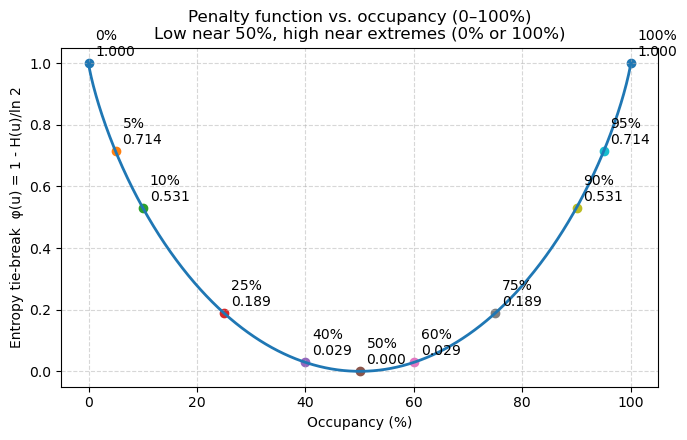

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def phi_entropy(u, eps=1e-12):
    u = np.clip(u, eps, 1.0 - eps)
    H = -(u * np.log(u) + (1 - u) * np.log(1 - u))        # natural log
    return 1.0 - H / np.log(2.0)                           # normalize to [0,1]

# Occupancy percent (0..100)
x_pct = np.linspace(0, 100, 1001)
u = x_pct / 100.0
phi = phi_entropy(u)

# Key sample points for reference
samples = {
    "0%": 0.0,
    '5%': 0.05,
    "10%": 0.10,
    "25%": 0.25,
    '40%': 0.40,
    "50%": 0.50,
    '60%': 0.60,
    "75%": 0.75,
    "90%": 0.90,
    "95%": 0.95,
    "100%": 1.0
}
sample_vals = {k: float(phi_entropy(np.array([v]))[0]) for k, v in samples.items()}

# Plot
plt.figure(figsize=(7, 4.5))
plt.plot(x_pct, phi, linewidth=2)
plt.xlabel("Occupancy (%)")
plt.ylabel("Entropy tie-break  φ(u) = 1 - H(u)/ln 2")
plt.title("Penalty function vs. occupancy (0–100%)\nLow near 50%, high near extremes (0% or 100%)")
plt.grid(True, linestyle="--", alpha=0.5)

# Annotate a few points
for label, occ in samples.items():
    y = phi_entropy(np.array([occ]))[0]
    plt.scatter([occ*100], [y])
    plt.annotate(f"{label}\n{y:.3f}", (occ*100, y),
                 textcoords="offset points", xytext=(5,5))


plt.tight_layout()
plt.show()

Cargadas 180 filas de resultados de ../runs/experimentos_algoritmos.xlsx
Columnas disponibles en el Excel:
['algorithm', 'rho', 'p', 'seed', 'best_fitness', 'Z_max', 'demanda_no_atendida', 'num_ciudades_no_asignadas', 'time_sec', 'H_dias', 'LOS', 'occ']
Usando columna 'algorithm' como nombre de algoritmo.
Usando columna 'Z_max' como Z.
Usando columna 'demanda_no_atendida' como demanda no atendida / penalización.
Usando columna 'time_sec' como tiempo de ejecución.

=== RESUMEN AGRUPADO (primeras filas) ===
  algorithm    rho   p  n_runs  best_fitness_mean  best_fitness_std  \
0      acme  0.001   5       5         133.530226          0.000008   
1      acme  0.001   8       5         112.371505          0.304800   
2      acme  0.001  10       5         102.871102          0.330187   
3      acme  0.005  14       5         149.037729          1.317252   
4      acme  0.005  17       5         120.955205          3.225649   

       Z_mean     Z_std  feas_rate  runtime_mean  runtime_std 

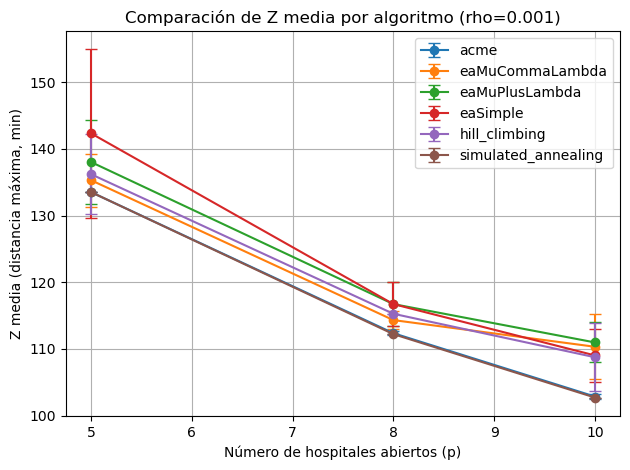

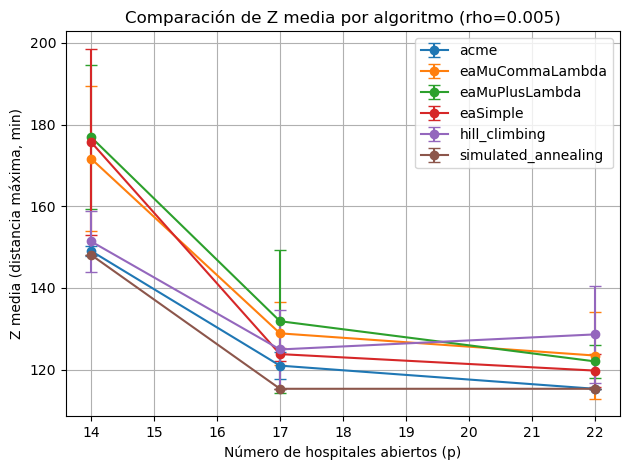

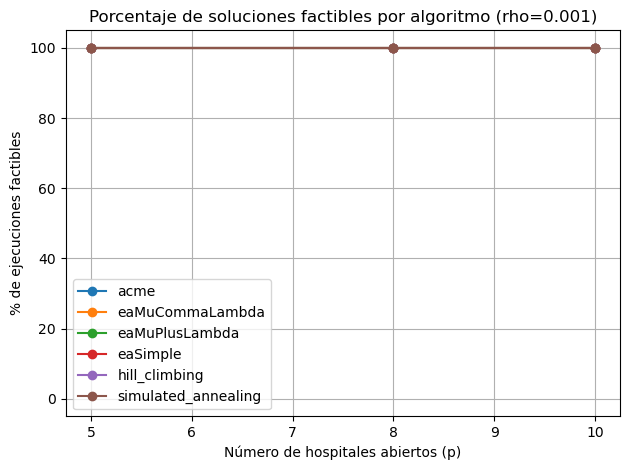

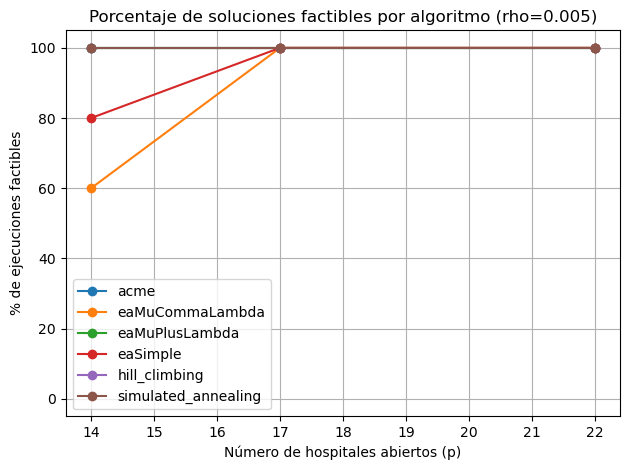

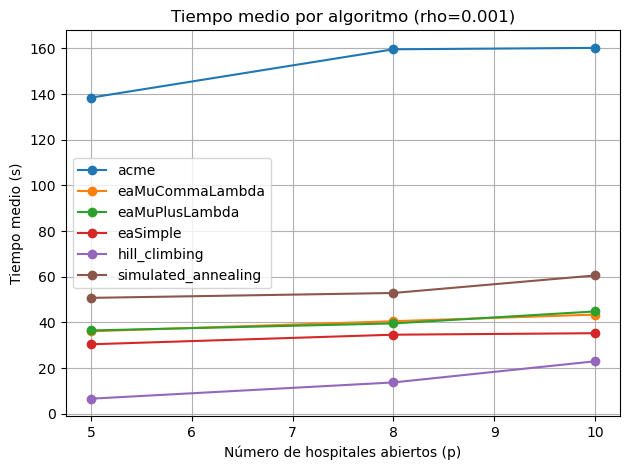

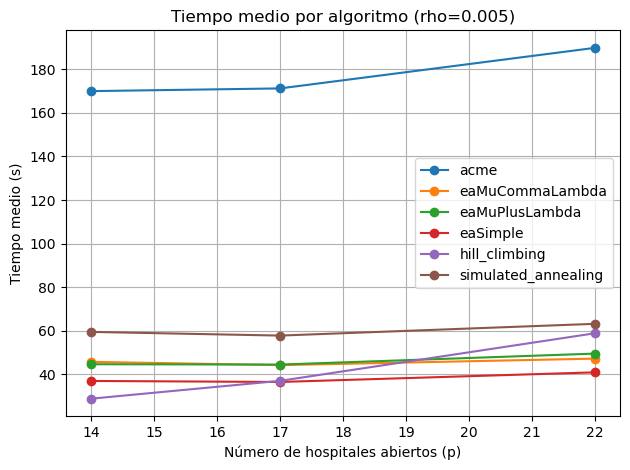


=== MEJOR ALGORITMO POR (rho, p) ===
     rho   p      algoritmo_mejor  Z_mean_mejor  Z_std_mejor  \
0  0.001   5                 acme    133.530000          0.0   
1  0.001   8  simulated_annealing    112.235000          0.0   
2  0.001  10  simulated_annealing    102.723333          0.0   
3  0.005  14  simulated_annealing    148.075000          0.0   
4  0.005  17  simulated_annealing    115.285000          0.0   
5  0.005  22                 acme    115.285000          0.0   

   feas_rate_%_mejor  runtime_mean_mejor  
0              100.0          138.428661  
1              100.0           52.890777  
2              100.0           60.561861  
3              100.0           59.512610  
4              100.0           57.823341  
5              100.0          189.815888  


In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_PATH = "../runs/experimentos_algoritmos.xlsx"
OUT_DIR = "../runs/analisis"
os.makedirs(OUT_DIR, exist_ok=True)


def cargar_resultados(path=RESULTS_PATH) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"No se encontró el fichero de resultados: {path}")
    df = pd.read_excel(path)
    print(f"Cargadas {len(df)} filas de resultados de {path}")
    print("Columnas disponibles en el Excel:")
    print(list(df.columns))
    return df


# --------- Detectores de nombres de columna --------- #

def detectar_columna_algoritmo(df: pd.DataFrame) -> str:
    candidatos = ["algorithm", "algoritmo"]
    for col in candidatos:
        if col in df.columns:
            print(f"Usando columna '{col}' como nombre de algoritmo.")
            return col
    raise KeyError("No se encontró una columna de algoritmo ('algorithm' o 'algoritmo').")


def detectar_columna_Z(df: pd.DataFrame) -> str:
    candidatos = ["Z_max", "Z", "z_max"]
    for col in candidatos:
        if col in df.columns:
            print(f"Usando columna '{col}' como Z.")
            return col
    raise KeyError("No se encontró una columna de Z ('Z_max' o 'Z').")


def detectar_columna_penalizacion(df: pd.DataFrame) -> str | None:
    candidatos = [
        "demanda_no_atendida",
        "penalty_unserved",
        "unserved",
        "unserved_demand",
        "penalizacion",
    ]
    for col in candidatos:
        if col in df.columns:
            print(f"Usando columna '{col}' como demanda no atendida / penalización.")
            return col
    print("⚠ No se encontró columna de penalización/demanda no atendida.")
    return None


def detectar_columna_tiempo(df: pd.DataFrame) -> str | None:
    candidatos = [
        "time_sec",
        "runtime_sec",
        "tiempo_s",
        "tiempo_segundos",
    ]
    for col in candidatos:
        if col in df.columns:
            print(f"Usando columna '{col}' como tiempo de ejecución.")
            return col
    print("⚠ No se encontró columna de tiempo de ejecución.")
    return None


# --------- Tabla de resumen --------- #

def tabla_resumen(df: pd.DataFrame) -> pd.DataFrame:
    """
    Tabla de resumen por (algoritmo, rho, p):
      - nº ejecuciones
      - media y std del fitness
      - media y std de Z
      - % de ejecuciones factibles (si hay penalización)
      - media del tiempo (si hay columna de tiempo)
    """
    df = df.copy()

    alg_col = detectar_columna_algoritmo(df)
    Z_col = detectar_columna_Z(df)
    penalty_col = detectar_columna_penalizacion(df)
    time_col = detectar_columna_tiempo(df)

    # Factibilidad
    if penalty_col is not None:
        df["factible"] = df[penalty_col] <= 1e-6
    else:
        df["factible"] = np.nan

    grp = df.groupby([alg_col, "rho", "p"])

    agg_dict = {
        "n_runs": ("seed", "count"),
        "best_fitness_mean": ("best_fitness", "mean"),
        "best_fitness_std": ("best_fitness", "std"),
        "Z_mean": (Z_col, "mean"),
        "Z_std": (Z_col, "std"),
    }

    if penalty_col is not None:
        agg_dict["feas_rate"] = ("factible", "mean")

    if time_col is not None:
        agg_dict["runtime_mean"] = (time_col, "mean")
        agg_dict["runtime_std"] = (time_col, "std")

    resumen = grp.agg(**agg_dict).reset_index(names=[alg_col, "rho", "p"])

    if "feas_rate" in resumen.columns:
        resumen["feas_rate_%"] = 100 * resumen["feas_rate"]
    else:
        resumen["feas_rate_%"] = np.nan

    out_csv = os.path.join(OUT_DIR, "resumen_por_alg_rho_p.csv")
    #resumen.to_csv(out_csv, index=False)
    #print(f"Tabla de resumen guardada en: {out_csv}")
    return resumen, alg_col


# --------- Gráficos --------- #

def plot_Z_vs_p_por_rho(resumen: pd.DataFrame, alg_col: str):
    for rho_val in sorted(resumen["rho"].unique()):
        df_rho = resumen[resumen["rho"] == rho_val].copy()
        if df_rho.empty:
            continue

        plt.figure()
        for alg in sorted(df_rho[alg_col].unique()):
            sub = df_rho[df_rho[alg_col] == alg].sort_values("p")
            if sub.empty:
                continue
            xs = sub["p"].values
            ys = sub["Z_mean"].values
            yerr = sub["Z_std"].values
            plt.errorbar(xs, ys, yerr=yerr, marker="o", capsize=4, label=alg)

        plt.xlabel("Número de hospitales abiertos (p)")
        plt.ylabel("Z media (distancia máxima, min)")
        plt.title(f"Comparación de Z media por algoritmo (rho={rho_val})")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()

        out_png = os.path.join(OUT_DIR, f"Z_vs_p_rho_{rho_val}.png")
        #plt.savefig(out_png, dpi=150)
        #plt.close()
        #print(f"Gráfico Z_vs_p para rho={rho_val} guardado en: {out_png}")
        plt.show()


def plot_factibilidad_vs_p(resumen: pd.DataFrame, alg_col: str):
    if "feas_rate_%" not in resumen.columns or resumen["feas_rate_%"].isna().all():
        print("⚠ No se puede graficar factibilidad: no hay datos de 'feas_rate_%'.")
        return

    for rho_val in sorted(resumen["rho"].unique()):
        df_rho = resumen[resumen["rho"] == rho_val].copy()
        if df_rho.empty:
            continue

        plt.figure()
        for alg in sorted(df_rho[alg_col].unique()):
            sub = df_rho[df_rho[alg_col] == alg].sort_values("p")
            if sub.empty:
                continue
            xs = sub["p"].values
            ys = sub["feas_rate_%"].values
            plt.plot(xs, ys, marker="o", label=alg)

        plt.xlabel("Número de hospitales abiertos (p)")
        plt.ylabel("% de ejecuciones factibles")
        plt.ylim(-5, 105)
        plt.title(f"Porcentaje de soluciones factibles por algoritmo (rho={rho_val})")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()

        out_png = os.path.join(OUT_DIR, f"factibilidad_vs_p_rho_{rho_val}.png")
        #plt.savefig(out_png, dpi=150)
        #plt.close()
        #print(f"Gráfico factibilidad_vs_p para rho={rho_val} guardado en: {out_png}")
        plt.show()


def plot_tiempo_vs_p(resumen: pd.DataFrame, alg_col: str):
    if "runtime_mean" not in resumen.columns or resumen["runtime_mean"].isna().all():
        print("⚠ No se puede graficar tiempo: no hay 'runtime_mean' en el resumen.")
        return

    for rho_val in sorted(resumen["rho"].unique()):
        df_rho = resumen[resumen["rho"] == rho_val].copy()
        if df_rho.empty:
            continue

        plt.figure()
        for alg in sorted(df_rho[alg_col].unique()):
            sub = df_rho[df_rho[alg_col] == alg].sort_values("p")
            if sub.empty:
                continue
            xs = sub["p"].values
            ys = sub["runtime_mean"].values
            plt.plot(xs, ys, marker="o", label=alg)

        plt.xlabel("Número de hospitales abiertos (p)")
        plt.ylabel("Tiempo medio (s)")
        plt.title(f"Tiempo medio por algoritmo (rho={rho_val})")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()

        out_png = os.path.join(OUT_DIR, f"tiempo_vs_p_rho_{rho_val}.png")
        #plt.savefig(out_png, dpi=150)
        #plt.close()
        #print(f"Gráfico tiempo_vs_p para rho={rho_val} guardado en: {out_png}")
        plt.show()


# --------- Tabla del mejor algoritmo por (rho, p) --------- #

def tabla_mejor_algoritmo_por_config(resumen: pd.DataFrame, alg_col: str) -> pd.DataFrame:
    filas = []
    for (rho_val, p_val), sub in resumen.groupby(["rho", "p"]):
        sub_sorted = sub.sort_values("Z_mean")
        best_row = sub_sorted.iloc[0]
        filas.append({
            "rho": rho_val,
            "p": p_val,
            "algoritmo_mejor": best_row[alg_col],
            "Z_mean_mejor": best_row["Z_mean"],
            "Z_std_mejor": best_row["Z_std"],
            "feas_rate_%_mejor": best_row.get("feas_rate_%", np.nan),
            "runtime_mean_mejor": best_row.get("runtime_mean", np.nan),
        })

    df_best = pd.DataFrame(filas).sort_values(["rho", "p"])
    out_csv = os.path.join(OUT_DIR, "mejor_algoritmo_por_rho_p.csv")
    #df_best.to_csv(out_csv, index=False)
    #print(f"Tabla de mejor algoritmo por (rho,p) guardada en: {out_csv}")
    return df_best


# --------- main --------- #

def main():
    df = cargar_resultados()
    resumen, alg_col = tabla_resumen(df)

    print("\n=== RESUMEN AGRUPADO (primeras filas) ===")
    print(resumen.head())

    plot_Z_vs_p_por_rho(resumen, alg_col)
    plot_factibilidad_vs_p(resumen, alg_col)
    plot_tiempo_vs_p(resumen, alg_col)

    df_best = tabla_mejor_algoritmo_por_config(resumen, alg_col)
    print("\n=== MEJOR ALGORITMO POR (rho, p) ===")
    print(df_best)


if __name__ == "__main__":
    main()


In [17]:
import math
import os
import pandas as pd
import numpy as np

ALG_ORDER = [
    "acme",
    'acme_no_sa',
    "eaSimple",
    "eaMuCommaLambda",
    "eaMuPlusLambda",
    "hill_climbing",
    "simulated_annealing",
    
]

def tabla_resumen(df: pd.DataFrame) -> tuple[pd.DataFrame, str]:
    """
    Tabla de resumen por (algoritmo, rho, p) para LaTeX:
      - n_runs
      - Z_mean y Z_ci95_pm (semianchura IC95 -> para escribir mean ± Z_ci95_pm)
      - runtime_mean y runtime_ci95_pm
      - % ejecuciones factibles
      Todas las magnitudes numéricas se redondean a 4 decimales.
    """
    df = df.copy()

    alg_col = detectar_columna_algoritmo(df)
    Z_col = detectar_columna_Z(df)
    penalty_col = detectar_columna_penalizacion(df)
    time_col = detectar_columna_tiempo(df)

    # Factibilidad
    if penalty_col is not None:
        df["factible"] = df[penalty_col] <= 1e-6
    else:
        df["factible"] = np.nan

    # Agrupación por (algoritmo, rho, p)
    grp = df.groupby([alg_col, "rho", "p"])

    agg_dict = {
        "n_runs": ("seed", "count"),
        "Z_mean": (Z_col, "mean"),
        'Z_min': (Z_col, 'min'),
        "Z_std": (Z_col, "std"),
    }
    if penalty_col is not None:
        agg_dict["feas_rate"] = ("factible", "mean")
    if time_col is not None:
        agg_dict["runtime_mean"] = (time_col, "mean")
        agg_dict["runtime_std"] = (time_col, "std")

    resumen = grp.agg(**agg_dict).reset_index(names=[alg_col, "rho", "p"])

    # % factibilidad
    if "feas_rate" in resumen.columns:
        resumen["feas_rate_%"] = 100 * resumen["feas_rate"]
    else:
        resumen["feas_rate_%"] = np.nan

    # ---------- Cálculo de IC95% (semianchura) ---------- #
    def halfwidth(std, n):
        if n is None or n <= 1 or pd.isna(std):
            return np.nan
        t_crit = 2.776  # para n=5
        return t_crit * std / math.sqrt(n)

    # Z
    resumen["Z_ci95_pm"] = resumen.apply(
        lambda r: halfwidth(r["Z_std"], r["n_runs"]), axis=1
    )

    # Tiempo (si existe)
    if "runtime_mean" in resumen.columns:
        resumen["runtime_ci95_pm"] = resumen.apply(
            lambda r: halfwidth(r["runtime_std"], r["n_runs"]), axis=1
        )
    else:
        resumen["runtime_ci95_pm"] = np.nan

    # --------- DataFrame final para la tabla en LaTeX --------- #
    cols_tabla = [
        "rho",
        "p",
        alg_col,
        "Z_min",
        "Z_mean",
        "Z_ci95_pm",
        "runtime_mean",
        "runtime_ci95_pm",
        "feas_rate_%",
        "n_runs",
    ]
    df_tabla = resumen[cols_tabla].copy()

    # Orden explícito de algoritmos
    df_tabla[alg_col] = pd.Categorical(
        df_tabla[alg_col],
        categories=ALG_ORDER,
        ordered=True,
    )

    # Orden final: rho, p, algoritmo
    df_tabla = df_tabla.sort_values(by=["rho", "p", alg_col]).reset_index(drop=True)

    # --------- Redondear a 4 decimales --------- #
    numeric_cols = df_tabla.select_dtypes(include=[float, int]).columns
    # No redondeamos n_runs a decimales, lo dejamos entero
    numeric_cols = [c for c in numeric_cols if c != "n_runs"]
    df_tabla[numeric_cols] = df_tabla[numeric_cols].round(4)

    # Guardar CSV “limpio” para LaTeX (opcional)
    out_csv = os.path.join(OUT_DIR, "resumen_para_tabla_ordenado.csv")
    df_tabla.to_csv(out_csv, index=False)
    print(f"Tabla resumida y ordenada para LaTeX guardada en: {out_csv}")

    return df_tabla, alg_col



df = cargar_resultados(RESULTS_PATH)
df_tabla, alg_col = tabla_resumen(df)
display(df_tabla)


Cargadas 210 filas de resultados de ../runs/experimentos_algoritmos.xlsx
Columnas disponibles en el Excel:
['algorithm', 'rho', 'p', 'seed', 'best_fitness', 'Z_max', 'demanda_no_atendida', 'num_ciudades_no_asignadas', 'time_sec', 'H_dias', 'LOS', 'occ']
Usando columna 'algorithm' como nombre de algoritmo.
Usando columna 'Z_max' como Z.
Usando columna 'demanda_no_atendida' como demanda no atendida / penalización.
Usando columna 'time_sec' como tiempo de ejecución.
Tabla resumida y ordenada para LaTeX guardada en: ../runs/analisis\resumen_para_tabla_ordenado.csv


,rho,p,algorithm,Z_min,Z_mean,Z_ci95_pm,runtime_mean,runtime_ci95_pm,feas_rate_%,n_runs
0,0.001,5,acme,133.5300,133.5300,0.0000,138.4287,3.6139,100.0,5
1,0.001,5,acme_no_sa,133.5300,133.5300,0.0000,125.0534,2.0861,100.0,5
2,0.001,5,eaSimple,133.5300,142.3430,15.7452,30.4383,1.2541,100.0,5
3,0.001,5,eaMuCommaLambda,133.5300,135.3147,4.9542,36.1304,1.0410,100.0,5
4,0.001,5,eaMuPlusLambda,133.5300,138.0407,7.8968,36.4792,2.1411,100.0,5
5,0.001,5,hill_climbing,133.5300,136.2153,7.4545,6.6223,2.5818,100.0,5
6,0.001,5,simulated_annealing,133.5300,133.5300,0.0000,50.7510,1.6451,100.0,5
7,0.001,8,acme,112.2350,112.3713,0.3785,159.5655,29.2040,100.0,5
8,0.001,8,acme_no_sa,112.2350,114.4160,1.5847,133.5701,5.8005,100.0,5
9,0.001,8,eaSimple,115.1217,116.7390,4.1506,34.6331,4.6594,100.0,5
